In [1]:
import pickle
import pandas as pd
import numpy as np

In [ ]:
trust_features = [
    "host_age_days",
    "description_length",
    "amenities_count",
    "host_response_rate",
    "number_of_reviews",
    "review_scores_rating",
    "price_vs_avg",
    "sentiment_score",
    "price_volatility",
    "availability_ratio",
    "review_to_listing_ratio",
    "host_identity_verified",
    "host_has_profile_pic",
    "instant_bookable"
]

X = listi[trust_features].fillna(0)

In [ ]:
X_sample = X.sample(500, random_state=42)

In [3]:
trust_model = pickle.load(open("../models/best_model.pkl", "rb"))

In [4]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/552.3 kB ? eta -:--:--
   ---------------------------------------- 552.3/552.3 kB 3.9 MB/s  0:00:00
   ---------------------------------------- 0.0/39.1 MB ? eta -:--:--
    --------------------------------------- 0.8/39.1 MB 4.9 MB/s eta 0:00:08
   -- ------------------------------------- 2.1/39.1 MB 4.9 MB/s eta 0:00:08
   --- ------------------------------------ 3.1/39.1 MB 5.0 MB/s eta 0:00:08
   ---- ----------------------------------- 4.2/39.1 MB 5.0 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/39.1 MB 5.1 MB/s eta 0:00:07
   ------ --------------------------------- 6.3/39.1 MB 5.0 MB/s eta 0:00:07
   ------- -------------------------------- 7.6/39.1 MB 5.1 MB/s eta 0:00:07
   -------- ------------------------------- 8.7/39.1 MB 5.0 MB/s eta 0:00:07
   --------- ------------------------------ 9.7/39.1 MB 5.2 MB/s eta 0:00:06
   --------

In [4]:
import shap

In [5]:
trust_model.classes_

array(['Neutral', 'Suspicious', 'Trustworthy'], dtype=object)

In [6]:
class_index = np.where(trust_model.classes_ == "Suspicious")[0][0]

In [7]:
X = pd.read_csv("trust_features_data.csv")

In [8]:
X_sample = X.sample(500, random_state=42)

In [9]:
explainer = shap.TreeExplainer(trust_model)

In [10]:
shap_values = explainer(X_sample)

In [11]:
shap_class = shap_values[:, :, class_index]

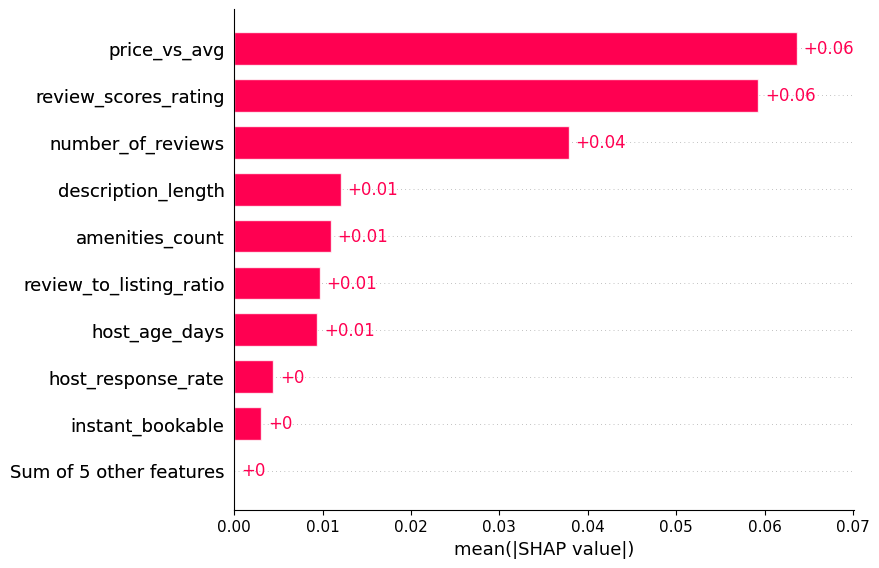

In [12]:
shap.plots.bar(shap_class)

In [13]:
sample_row = X_sample.iloc[0]
sample_shap = shap_class[0]

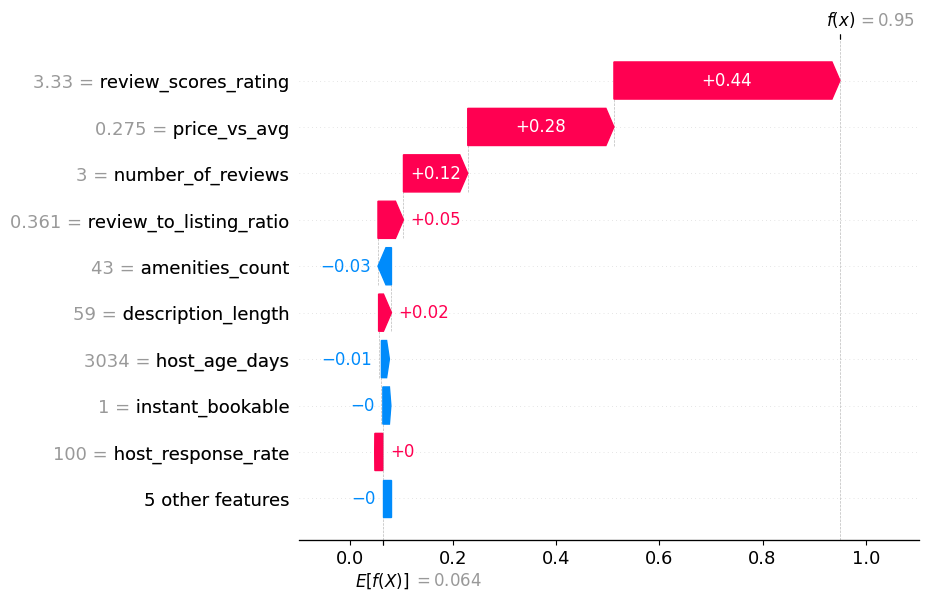

In [14]:
shap.plots.waterfall(sample_shap)

In [15]:
# Feature contributions for this listing
feature_values = sample_row.values
feature_names = X_sample.columns
contributions = sample_shap.values

In [17]:
explain_df = pd.DataFrame({
    "feature": feature_names,
    "value": feature_values,
    "impact": contributions
})
explain_df

,feature,value,impact
0,host_age_days,3034.000000,-0.005450
1,description_length,59.000000,0.024915
2,amenities_count,43.000000,-0.026119
3,host_response_rate,100.000000,0.000348
4,number_of_reviews,3.000000,0.124576
5,review_scores_rating,3.330000,0.437964
6,price_vs_avg,0.274796,0.283238
7,sentiment_score,0.000000,0.000000
8,price_volatility,0.000000,0.000000
9,availability_ratio,0.000000,0.000000


In [19]:
# Sort by highest positive impact (toward Suspicious)
explain_df = explain_df.sort_values(by="impact", ascending=False)
explain_df

,feature,value,impact
5,review_scores_rating,3.330000,0.437964
6,price_vs_avg,0.274796,0.283238
4,number_of_reviews,3.000000,0.124576
10,review_to_listing_ratio,0.360910,0.049374
1,description_length,59.000000,0.024915
3,host_response_rate,100.000000,0.000348
9,availability_ratio,0.000000,0.000000
11,host_identity_verified,NaN,0.000000
8,price_volatility,0.000000,0.000000
7,sentiment_score,0.000000,0.000000


In [20]:
print("Why this listing was flagged Suspicious:\n")
for i in range(3):
    row = explain_df.iloc[i]
    print(f"- {row['feature']} (value={row['value']}) increased risk by {round(row['impact'],3)}")

Why this listing was flagged Suspicious:

- review_scores_rating (value=3.33) increased risk by 0.438
- price_vs_avg (value=0.2747962061009997) increased risk by 0.283
- number_of_reviews (value=3.0) increased risk by 0.125


In [22]:
print("MODEL EXPLANATION:")
print("This listing was flagged Suspicious because:")
for i in range(3):
    row = explain_df.iloc[i]
    print(f"• {row['feature']} = {row['value']} strongly contributed to risk")

MODEL EXPLANATION:
This listing was flagged Suspicious because:
• review_scores_rating = 3.33 strongly contributed to risk
• price_vs_avg = 0.2747962061009997 strongly contributed to risk
• number_of_reviews = 3.0 strongly contributed to risk


In [25]:
price_model = pickle.load(open("../models/best_price_model.pkl", "rb"))

In [26]:
price_importance = price_model.get_booster().get_score(importance_type="weight")

In [27]:
price_imp_df = pd.DataFrame(
    price_importance.items(),
    columns=["feature", "importance"]
).sort_values(by="importance", ascending=False)

price_imp_df

,feature,importance
6,latitude,32792.0
7,longitude,30386.0
3,amenities_count,28490.0
8,review_scores_rating,18260.0
0,accommodates,17207.0
5,neighbourhood_enc,10832.0
1,bathrooms,9397.0
2,bedrooms,7905.0
4,room_type_enc,3705.0


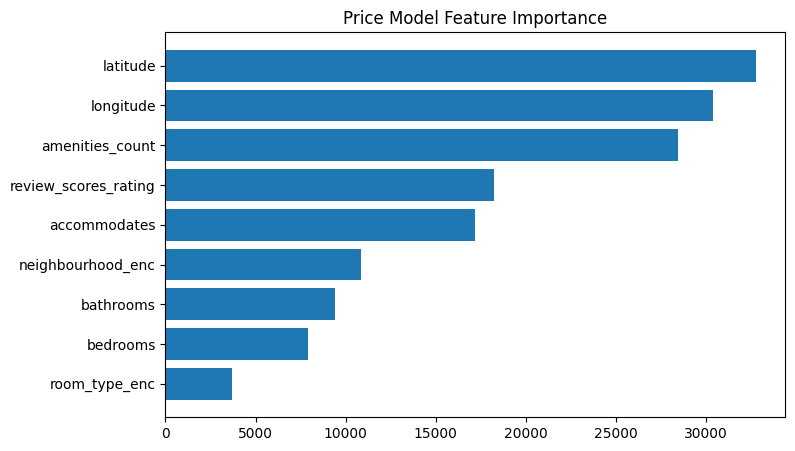

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(price_imp_df["feature"], price_imp_df["importance"])
plt.gca().invert_yaxis()
plt.title("Price Model Feature Importance")
plt.show()